# 🛒 Vietnamese Graph RAG — Part 2: Knowledge Graph + RAG
**ĐH KHTN, ĐHQG-HCM — NLP Final Project**

Tái hiện **số liệu thật** của báo cáo:
- **Module 4** — Knowledge Graph hợp nhất (UIT-ViSFD + Shopee) + trực quan.
- **TN3** — Ablation retrieval (bi-encoder → +MaxSim → +Graph boost) bằng P@k/MRR (không rò rỉ metric).
- **TN4** — Demo end-to-end: Retrieve → Graph context → sinh câu trả lời (LLM qua proxy OpenAI-compatible).

> Tái dùng package `src/vngraphrag`. Cần đã `make index` (build index PhoBERT + KG) và có `.env` (OPENAI_API_KEY + OPENAI_BASE_URL).

## ⚙️ Bootstrap (Kaggle / local tự nhận diện)
Trên **Kaggle**: cài thư viện + clone repo + build index/KG + train BiLSTM nếu thiếu (GPU T4) +
lấy khoá LLM từ **Add-ons → Secrets** (`OPENAI_API_KEY`, tuỳ chọn `OPENAI_BASE_URL` nếu dùng proxy).
Trên **local**: bỏ qua (đã có repo + `.env`).

In [1]:
import os, subprocess
ON_KAGGLE = os.path.exists('/kaggle')
REPO = 'https://github.com/lphhien112-gif/vietnamese-graph-rag.git'
if ON_KAGGLE:
    subprocess.run('pip install -q underthesea transformers scikit-learn scipy networkx matplotlib openai gradio', shell=True)
    if not os.path.isdir('/kaggle/working/vietnamese-graph-rag'):
        subprocess.run(f'cd /kaggle/working && git clone -q {REPO}', shell=True)
    os.chdir('/kaggle/working/vietnamese-graph-rag')
    for f, cmd in [('artifacts/doc_vectors.npy','vngraphrag.cli.build_index'),
                   ('artifacts/aspect_clf.pt','vngraphrag.cli.train_aspect')]:
        if not os.path.exists(f):
            print('Đang chạy', cmd, '...'); subprocess.run(f'python -m {cmd}', shell=True)
    try:
        from kaggle_secrets import UserSecretsClient
        sec = UserSecretsClient()
        os.environ['OPENAI_API_KEY'] = sec.get_secret('OPENAI_API_KEY')
        try: os.environ['OPENAI_BASE_URL'] = sec.get_secret('OPENAI_BASE_URL')
        except Exception: pass
    except Exception as e:
        print('⚠️ Chưa có secret OPENAI_API_KEY — phần sinh câu trả lời sẽ fallback:', e)
print('Môi trường:', 'Kaggle' if ON_KAGGLE else 'local')

Môi trường: local


## 0. Thiết lập

In [2]:
import sys, os, json
from pathlib import Path
import numpy as np
ROOT = Path.cwd(); ROOT = ROOT if (ROOT/'src').exists() else ROOT.parent
os.chdir(ROOT)                       # path tương đối (artifacts/, data/raw) trỏ đúng repo root
sys.path.insert(0, str(ROOT/'src'))
from vngraphrag.config import Config
cfg = Config.load(ROOT/'config.yaml')
print('artifacts_dir =', cfg.artifacts_dir, '| model =', cfg.llm.model)

artifacts_dir = artifacts | model = gpt-5.4-mini


## 1. Knowledge Graph hợp nhất + thống kê

In [3]:
from vngraphrag.core import load_visfd, load_shopee, load_kg
from vngraphrag.core.aspect_clf import AspectClassifier
from collections import Counter
G = load_kg(Path(cfg.artifacts_dir)/'kg.pkl')
types = Counter(d.get('type') for _,d in G.nodes(data=True))
rels  = Counter(d.get('relation') for *_,d in G.edges(data=True))
print(f'KG: {G.number_of_nodes()} node, {G.number_of_edges()} cạnh')
print('node types:', dict(types)); print('edge relations:', dict(rels))

KG: 102 node, 353 cạnh
node types: {'aspect': 10, 'sentiment': 30, 'brand': 12, 'shop': 24, 'product': 26}
edge relations: {'has_sentiment': 30, 'reviewed_on': 105, 'sells': 26, 'mentions': 192}


### 1.1 Truy vấn KG: phân bố cảm xúc theo aspect

In [4]:
from vngraphrag.core import graph_query
for asp in ['CAMERA','BATTERY','SER&ACC']:
    sd = graph_query(G, asp); tot = sum(v['count'] for v in sd.values())
    print(f'\n{asp}:')
    for node, inf in sorted(sd.items(), key=lambda x:-x[1]['count']):
        print(f"  {inf['sentiment']:9} {inf['count']:5}  ({100*inf['count']/tot:.0f}%)")


CAMERA:
  Positive   1231  (57%)
  Negative    627  (29%)
  Neutral     288  (13%)

BATTERY:
  Positive   2027  (56%)
  Negative   1228  (34%)
  Neutral     349  (10%)

SER&ACC:
  Positive   1401  (70%)
  Negative    487  (24%)
  Neutral     107  (5%)


### 1.2 Trực quan KG (brand → aspect → sentiment)

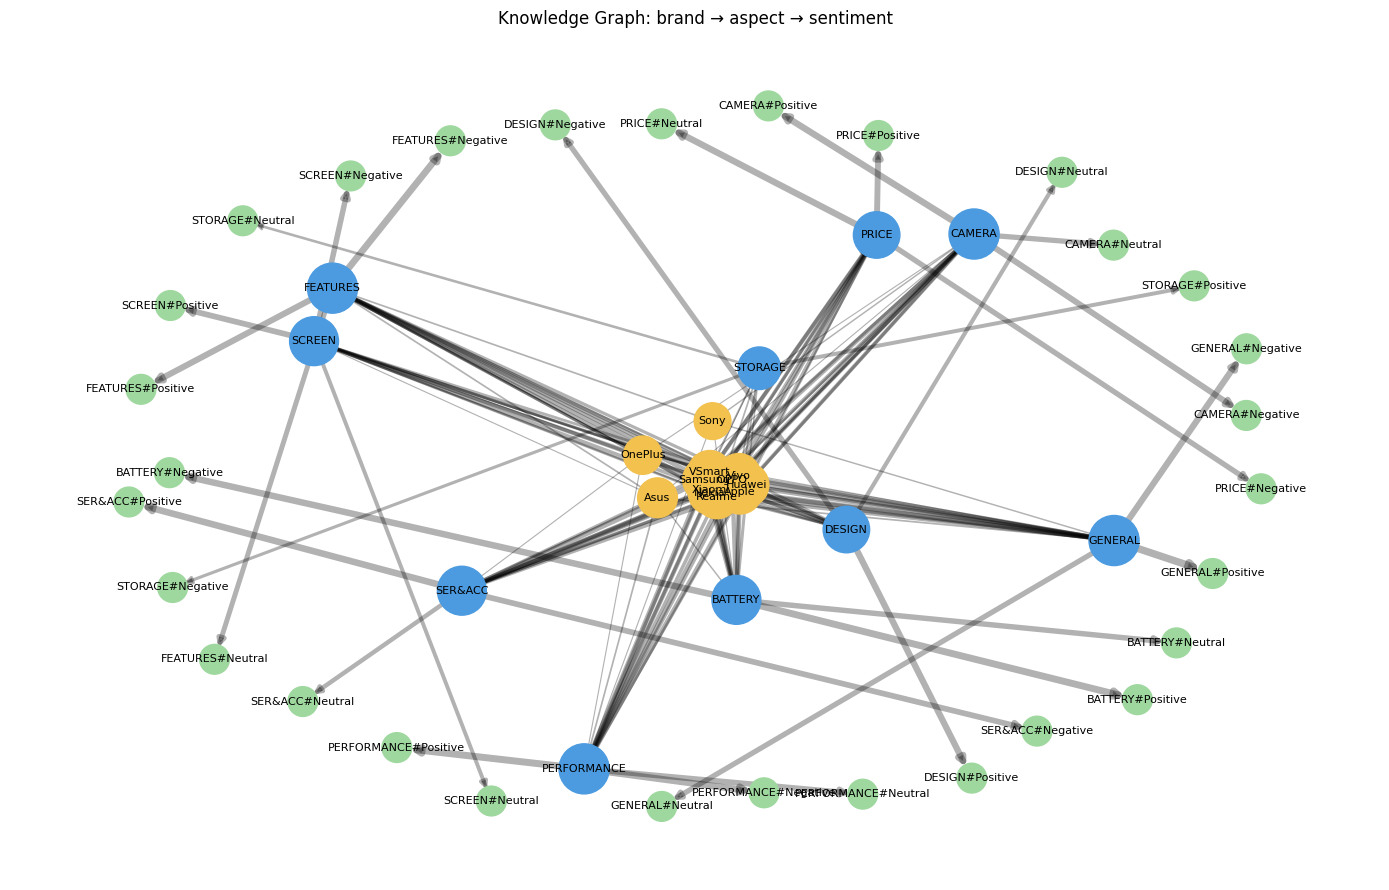

In [5]:
import matplotlib.pyplot as plt, networkx as nx, math
keep=[n for n,d in G.nodes(data=True) if d.get('type') in ('brand','aspect','sentiment')]
H=G.subgraph(keep)
col={'aspect':'#4C9BE0','sentiment':'#9FD89F','brand':'#F2C14E'}
fig,ax=plt.subplots(figsize=(14,9)); pos=nx.spring_layout(H,k=0.9,seed=7,iterations=120)
nx.draw_networkx_nodes(H,pos,node_color=[col[H.nodes[n]['type']] for n in H],
                       node_size=[400+60*H.degree(n) for n in H],ax=ax)
nx.draw_networkx_edges(H,pos,width=[0.4+math.log1p(H[u][v]['weight'])*0.6 for u,v in H.edges()],alpha=0.3,ax=ax,arrows=True)
nx.draw_networkx_labels(H,pos,font_size=8,ax=ax); ax.axis('off')
ax.set_title('Knowledge Graph: brand → aspect → sentiment'); plt.tight_layout(); plt.show()

## 2. TN3 — Ablation retrieval (không rò rỉ metric)
Trên cùng Top-50 candidate, đổi trọng số 3 thành phần: bi-encoder · MaxSim · graph boost.
Graph boost dùng aspect *quan sát trong nội dung*; chấm điểm bằng *nhãn vàng* (độc lập → không rò rỉ).

In [6]:
from vngraphrag.cli.evaluate import run_eval, CONFIGS, EVAL_QUERIES
import pandas as pd
print(f'{len(EVAL_QUERIES)} truy vấn · {len(CONFIGS)} cấu hình')
results = run_eval(cfg)
eval_df = pd.DataFrame(results).T[['P@5','P@10','MRR']]
display(eval_df)

8 truy vấn · 3 cấu hình


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,P@5,P@10,MRR
bi_encoder,0.800,0.775,0.8333
attention,0.825,0.850,0.8333
graph_rag,0.825,0.850,0.8542


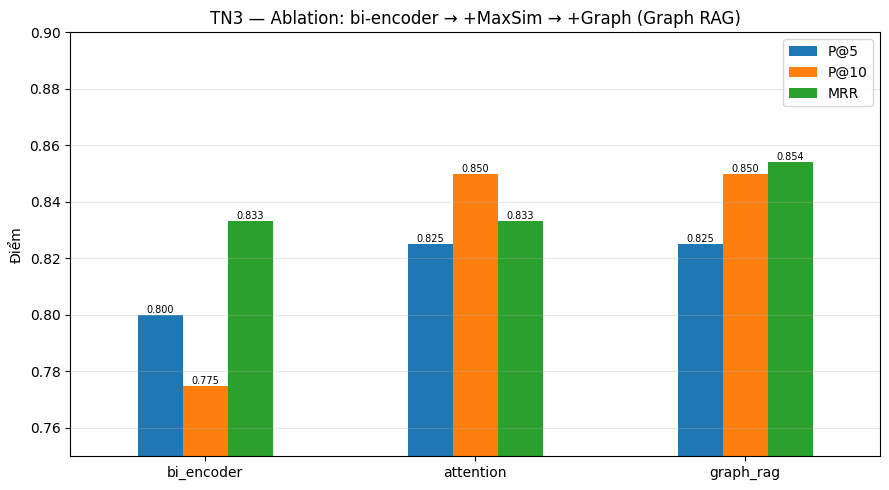

Graph RAG đạt MRR cao nhất = 0.8542


In [7]:
ax = eval_df.plot(kind='bar', figsize=(9,5), ylim=(0.75,0.90), rot=0)
ax.set_title('TN3 — Ablation: bi-encoder → +MaxSim → +Graph (Graph RAG)')
ax.set_ylabel('Điểm'); ax.grid(axis='y', alpha=0.3)
for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=7)
plt.tight_layout(); plt.show()
print('Graph RAG đạt MRR cao nhất =', max(r['MRR'] for r in results.values()))

## 3. TN4 — Demo end-to-end (Retrieve → Graph context → LLM)
Pipeline đầy đủ; LLM gọi qua proxy OpenAI-compatible (đọc từ .env).

In [8]:
from vngraphrag.rag.pipeline import GraphRAGPipeline
pipe = GraphRAGPipeline.from_artifacts(cfg)
print('LLM khả dụng:', pipe.generator.available, '| model:', pipe.generator.model)

for q in ["Camera điện thoại chụp đêm có tốt không?",
          "Pin Samsung dùng có lâu không?",
          "Dịch vụ bảo hành và nhân viên tư vấn thế nào?"]:
    r = pipe.answer(q)
    print('\n❓', q)
    print('📊 KG context:', r['graph_context'].strip().replace(chr(10),' | '))
    print('💬', r['answer'])
    print(f"⏱️ {r['latency_ms']}ms")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LLM khả dụng: True | model: gpt-5.4-mini



❓ Camera điện thoại chụp đêm có tốt không?
📊 KG context: - CAMERA/Positive: 1231 review (57%) | - CAMERA/Negative: 627 review (29%) | - CAMERA/Neutral: 288 review (13%)
💬 Có, theo đánh giá thì camera chụp đêm khá tốt.
⏱️ 5392.0ms



❓ Pin Samsung dùng có lâu không?
📊 KG context: - BATTERY/Positive: 2027 review (56%) | - BATTERY/Negative: 1228 review (34%) | - BATTERY/Neutral: 349 review (10%)
💬 Có vẻ **pin Samsung khá tốt**, vì trong dữ liệu phần **BATTERY/Positive chiếm 56%**. Tuy nhiên vẫn có một số phản hồi **pin nhanh hết, sạc nóng hoặc lỗi sạc**.
⏱️ 5808.8ms



❓ Dịch vụ bảo hành và nhân viên tư vấn thế nào?
📊 KG context: - SER&ACC/Positive: 1401 review (70%) | - SER&ACC/Negative: 487 review (24%) | - SER&ACC/Neutral: 107 review (5%)
💬 Dịch vụ bảo hành và chăm sóc khách hàng nhìn chung **khá tốt**, được khen là **hỗ trợ tốt, hậu mãi vượt trội**. Tuy nhiên vẫn có phản hồi **chưa tốt ở một số nơi**, như **bảo hành thiếu trách nhiệm** hoặc **dịch vụ liên kết kém**.
⏱️ 4685.6ms


## 4. Export artifacts (đã có sẵn từ `make index`)

In [9]:
import os
for f in ['doc_vectors.npy','records.json','manifest.json','kg.pkl','aspect_clf.pt','metrics.json']:
    p = Path(cfg.artifacts_dir)/f
    print(f"  {'✅' if p.exists() else '❌'} {f}" + (f"  ({os.path.getsize(p)//1024} KB)" if p.exists() else ''))

  ✅ doc_vectors.npy  (32769 KB)
  ✅ records.json  (3278 KB)
  ✅ manifest.json  (0 KB)
  ✅ kg.pkl  (25 KB)
  ✅ aspect_clf.pt  (4199 KB)
  ✅ metrics.json  (0 KB)


## 5. 🎛️ Giao diện Web (Gradio)
Cell dưới chỉ **dựng** UI (không `launch()` để nbconvert không treo). Khi chạy tương tác,
bỏ comment dòng `demo.launch(share=True)` để mở link demo `*.gradio.live`.

In [10]:
try:
    from app.ui import build_ui
    demo = build_ui()
    print('✅ Đã dựng Gradio UI. Để mở: demo.launch(share=True)')
    # demo.launch(share=True)   # <- bỏ comment khi chạy tương tác
except Exception as e:
    print('Gradio chưa sẵn sàng:', e)

✅ Đã dựng Gradio UI. Để mở: demo.launch(share=True)
